로드 완료  |  n=9,218,141  |  min=532.2677  max=1242.8093  mean=1157.1575
저장: plot_intensity.png


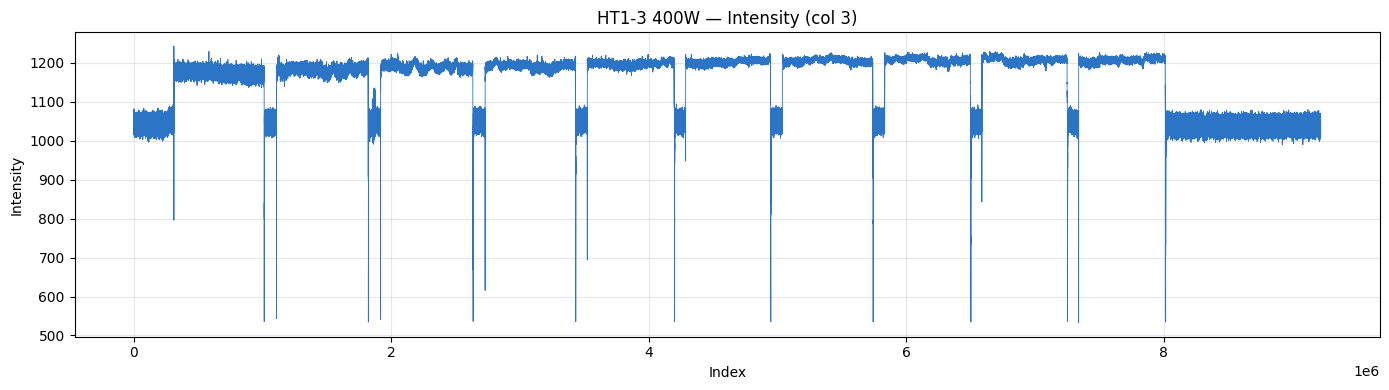

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

FILE = "/home/ftk3187/github/DPC_research/DATAFUSION/data_400w/HT1-3-(240820)_PD_exp02_Single Track Square.csv"

s = pd.read_csv(FILE, header=None, usecols=[2]).iloc[:, 0]
s.name = "intensity"
print(f"로드 완료  |  n={len(s):,}  |  min={s.min():.4f}  max={s.max():.4f}  mean={s.mean():.4f}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(s.index, s.values, linewidth=0.6, alpha=0.9, color="#1565C0")
ax.set_xlabel("Index")
ax.set_ylabel("Intensity")
ax.set_title("HT1-3 400W — Intensity (col 3)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plot_intensity.png", dpi=150, bbox_inches="tight")
print("저장: plot_intensity.png")
plt.show()

Top 5 peaks:
  freq=0.010848  amp=22.7845
  freq=0.021696  amp=18.2014
  freq=0.032545  amp=13.9047
  freq=0.130178  amp=12.0906
  freq=0.260356  amp=10.5428
저장: fft_intensity.png


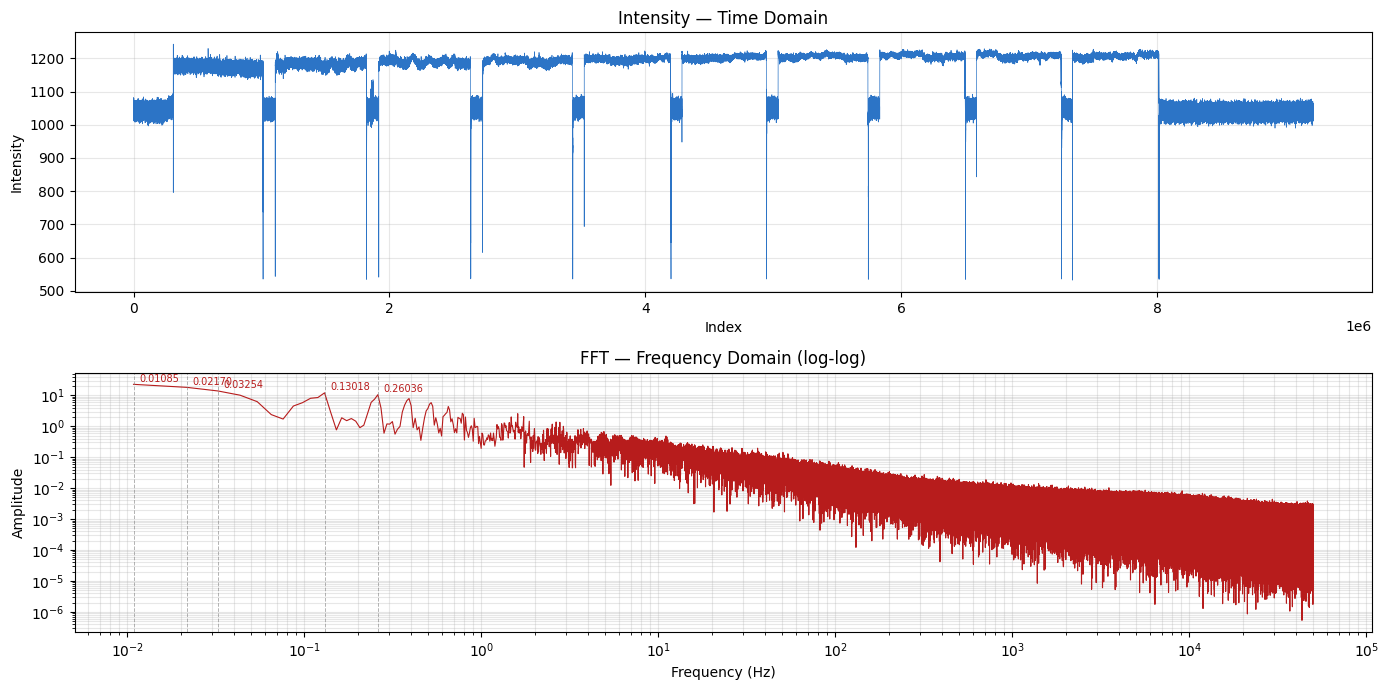

In [7]:
# 이전 셀에서 s 로드된 상태 가정
import numpy as np
import matplotlib.pyplot as plt

# ─── FFT ─────────────────────────────────────────────────────────────────────
sig = s.values
n   = len(sig)
dt  = 1 / 100000  # 100kHz

fft_vals = np.fft.rfft(sig - sig.mean())
fft_freq = np.fft.rfftfreq(n, d=dt)
fft_amp  = np.abs(fft_vals) / n

# DC(0번 bin) 명시적 제거
fft_freq_nz = fft_freq[1:]
fft_amp_nz  = fft_amp[1:]

# 상위 5개 피크
peak_idx = np.argsort(fft_amp_nz)[-5:][::-1]
print("Top 5 peaks:")
for pi in peak_idx:
    print(f"  freq={fft_freq_nz[pi]:.6f}  amp={fft_amp_nz[pi]:.4f}")

# ─── 플롯 ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# 상단: 원본 신호
axes[0].plot(sig, linewidth=0.5, alpha=0.9, color="#1565C0")
axes[0].set_title("Intensity — Time Domain")
axes[0].set_xlabel("Index")
axes[0].set_ylabel("Intensity")
axes[0].grid(True, alpha=0.3)

# 하단: FFT (log scale)
axes[1].plot(fft_freq_nz, fft_amp_nz, linewidth=0.8, color="#B71C1C")
for pi in peak_idx:
    axes[1].axvline(fft_freq_nz[pi], linewidth=0.7, linestyle="--", alpha=0.6, color="gray")
    axes[1].annotate(f"{fft_freq_nz[pi]:.5f}",
                     xy=(fft_freq_nz[pi], fft_amp_nz[pi]),
                     fontsize=7, xytext=(4, 2), textcoords="offset points", color="#B71C1C")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("FFT — Frequency Domain (log-log)")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Amplitude")
axes[1].grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.savefig("fft_intensity.png", dpi=150, bbox_inches="tight")
print("저장: fft_intensity.png")
plt.show()

Elbow 주파수 : 0.2604 Hz  (주기 3.84s)
Cutoff 설정  : 0.2604 Hz


/tmp/ipykernel_3087483/2319935347.py:72: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


저장: fft_filter_intensity.png


/home/ftk3187/miniconda3/envs/dpc/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


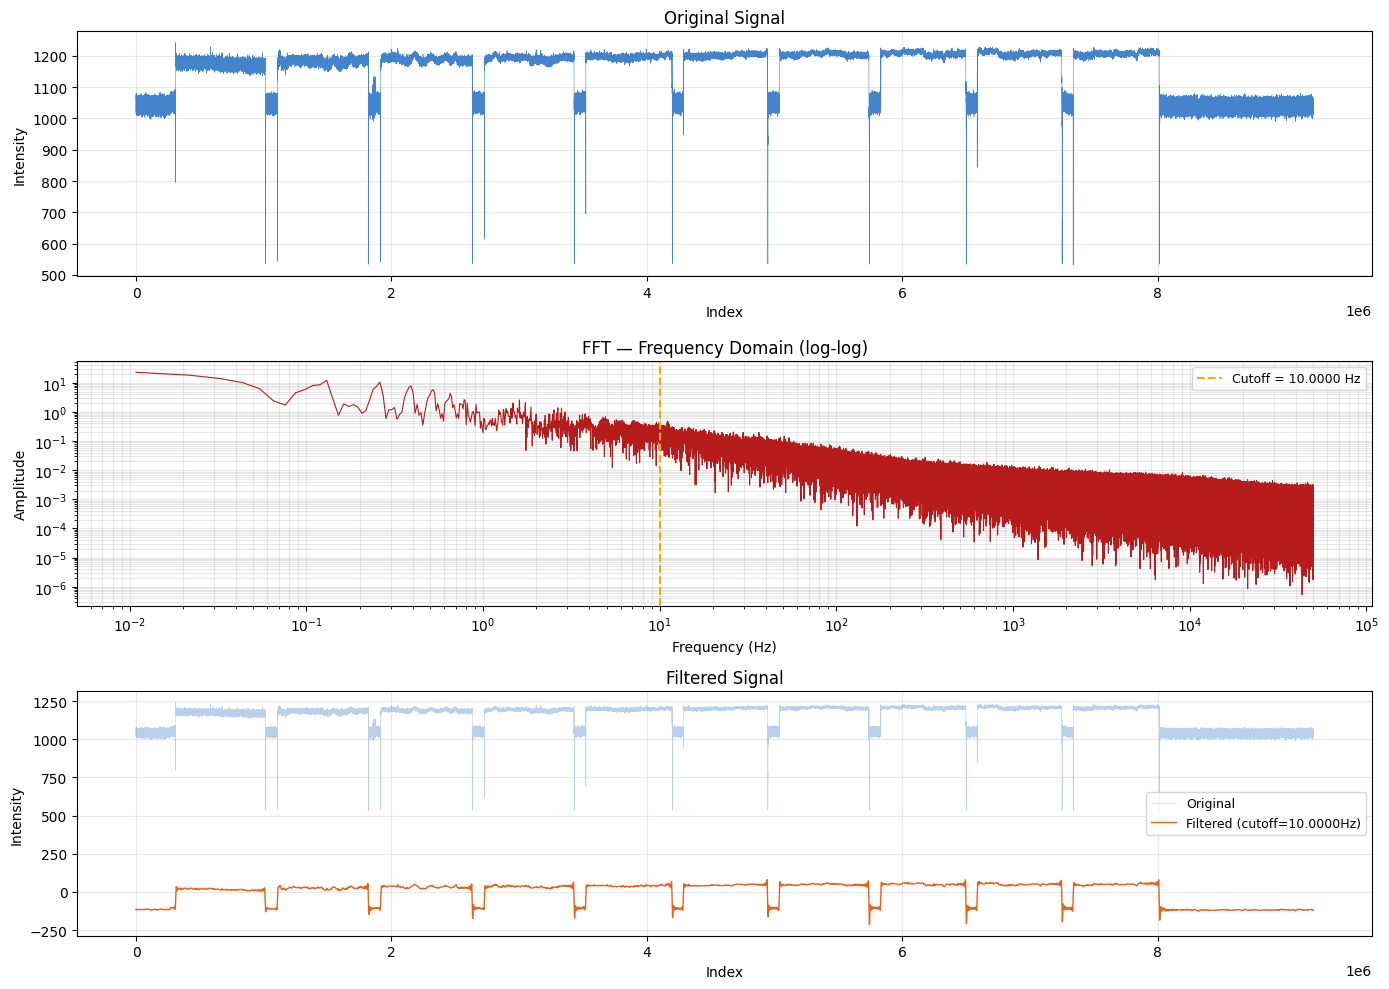

In [9]:
# 이전 셀에서 s 로드된 상태 가정
import numpy as np
import matplotlib.pyplot as plt

FS = 100_000
dt = 1 / FS

sig = s.values
n   = len(sig)

fft_vals = np.fft.rfft(sig - sig.mean())
fft_freq = np.fft.rfftfreq(n, d=dt)
fft_amp  = np.abs(fft_vals) / n

# DC 제거
freq_nz = fft_freq[1:]
amp_nz  = fft_amp[1:]

# ─── Elbow 찾기 (log 스케일에서 직선 대비 최대 편차 지점) ────────────────────
log_freq = np.log10(freq_nz)
log_amp  = np.log10(np.clip(amp_nz, 1e-10, None))

# 시작~끝 직선
p = np.polyfit([log_freq[0], log_freq[-1]], [log_amp[0], log_amp[-1]], 1)
line = np.polyval(p, log_freq)
deviation = log_amp - line
elbow_idx  = np.argmax(deviation)
elbow_freq = freq_nz[elbow_idx]

print(f"Elbow 주파수 : {elbow_freq:.4f} Hz  (주기 {1/elbow_freq:.2f}s)")
print(f"Cutoff 설정  : {elbow_freq:.4f} Hz")

# ─── FFT 필터링 ───────────────────────────────────────────────────────────────
#CUTOFF = elbow_freq  # 바꾸고 싶으면 여기만 수정
CUTOFF = 10

fft_filtered = fft_vals.copy()
fft_filtered[fft_freq > CUTOFF] = 0
sig_filtered = np.fft.irfft(fft_filtered, n=n)

# ─── 플롯 ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# 1행: 원본
axes[0].plot(sig, linewidth=0.4, alpha=0.8, color="#1565C0")
axes[0].set_title("Original Signal")
axes[0].set_xlabel("Index")
axes[0].set_ylabel("Intensity")
axes[0].grid(True, alpha=0.3)

# 2행: FFT + elbow 표시
axes[1].plot(freq_nz, amp_nz, linewidth=0.8, color="#B71C1C")
axes[1].axvline(CUTOFF, color="orange", linewidth=1.5, linestyle="--",
                label=f"Cutoff = {CUTOFF:.4f} Hz")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("FFT — Frequency Domain (log-log)")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Amplitude")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, which="both")

# 3행: 필터링 결과
axes[2].plot(sig,          linewidth=0.4, alpha=0.3, color="#1565C0", label="Original")
axes[2].plot(sig_filtered, linewidth=1.0, alpha=0.9, color="#E65100", label=f"Filtered (cutoff={CUTOFF:.4f}Hz)")
axes[2].set_title("Filtered Signal")
axes[2].set_xlabel("Index")
axes[2].set_ylabel("Intensity")
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig("fft_filter_intensity.png", dpi=150, bbox_inches="tight")
print("저장: fft_filter_intensity.png")
plt.show()